# pySCENIC gene regulatory network analysis of pre-processed data

[GitHub](https://github.com/aertslab/pySCENIC?tab=readme-ov-file#id16)  
[Tutorial](https://pyscenic.readthedocs.io/en/latest/tutorial.html)  
[Worflow publication](https://www.nature.com/articles/s41596-020-0336-2)  
[Data base](https://resources.aertslab.org/cistarget/databases/)  

[About group comparisions](https://github.com/aertslab/pySCENIC/issues/292)

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_rss

from arboreto.algo import grnboost2

import scanpy as sc
import loompy as lp

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

import glob

import os

In [5]:
import pyscenic

In [6]:
pyscenic.__version__

'0.12.1'

In [3]:
os.chdir('/research/peer/fdeckert/FD20220623HSCT')

In [4]:
# rpy2 
os.environ['R_HOME'] = '/nobackup/peer/fdeckert/miniconda3/envs/r.4.1.0-FD20220623HSCT/lib/R'

## Plotting 

In [5]:
sc.settings.vector_friendly = False

sc.set_figure_params(figsize=(5, 5), dpi_save=1200, fontsize=12, frameon=False, facecolor="white")
sc.settings.figdir = 'result/figures/'

In [6]:
sns.set()
sns.set(style='whitegrid', font_scale=0.8)

In [7]:
plt.rcParams.update(
    
    {
    
        'font.size': 12,          # Default font size
        'axes.titlesize': 12,     # Title font size
        'axes.labelsize': 12,     # X and Y label font size
        'xtick.labelsize': 10,    # X tick label font size
        'ytick.labelsize': 10,    # Y tick label font size
        'legend.fontsize': 12     # Legend font size

    }
        )

# Load pre-processed AnnData object

In [8]:
adata = sc.read_h5ad("data/object/pp_subset.h5ad")

In [9]:
adata = adata[adata.obs.domain_leiden_subset=="lymphocyte", ]
adata = adata[:, (adata.X>=1).sum(axis=0)>=3]

# Export loom file

In [10]:
row_attrs = {
    
    "Gene": np.array(adata.var_names),
}
col_attrs = {
    
    "CellID": np.array(adata.obs_names),
    "nGene": np.array(np.sum(adata.X.transpose()>0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata.X.transpose(), axis=0)).flatten(),
    
}

lp.create("data/object/scenic/lymphocyte.loom", adata.X.transpose(), row_attrs, col_attrs)

# pySCENIC workflow 

In [11]:
# Scenic data base files 
tf_file = "/nobackup/peer/fdeckert/scenic/hgnc/hs_hgnc_tfs.txt"
db_file = ' '.join(glob.glob("/nobackup/peer/fdeckert/scenic/hgnc/*feather"))
motif_file = "/nobackup/peer/fdeckert/scenic/hgnc/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl"

# Loom 
input_loom = "/research/peer/fdeckert/FD20220623HSCT/data/object/scenic/lymphocyte.loom"

# Result  
result_dir = "/research/peer/fdeckert/FD20220623HSCT/result/scenic/lymphocyte"
result_loom = "pyscenic.loom"

# Available workers 
num_workers = os.cpu_count()

In [12]:
os.chdir(result_dir)

In [13]:
# !/nobackup/peer/fdeckert/miniconda3/envs/pyscenic/bin/pyscenic grn {input_loom} {tf_file} \
#     --method grnboost2 \
#     --output adj.csv \
#     --num_workers {num_workers}

In [14]:
# !/nobackup/peer/fdeckert/miniconda3/envs/pyscenic/bin/pyscenic ctx adj.csv {db_file} \
#     --annotations_fname {motif_file} \
#     --expression_mtx_fname {input_loom} \
#     --output reg.csv \
#     --mask_dropouts \
#     --num_workers {num_workers}

In [15]:
# !/nobackup/peer/fdeckert/miniconda3/envs/pyscenic/bin/pyscenic aucell \
#     {input_loom} \
#     reg.csv \
#     --output {result_loom} \
#     --num_workers {num_workers}

In [16]:
lf = lp.connect(result_loom, mode='r+', validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
adata.obsm['X_regulon'] = auc_mtx
lf.close()

In [17]:
auc_mtx.to_csv('auc_mtx.csv')

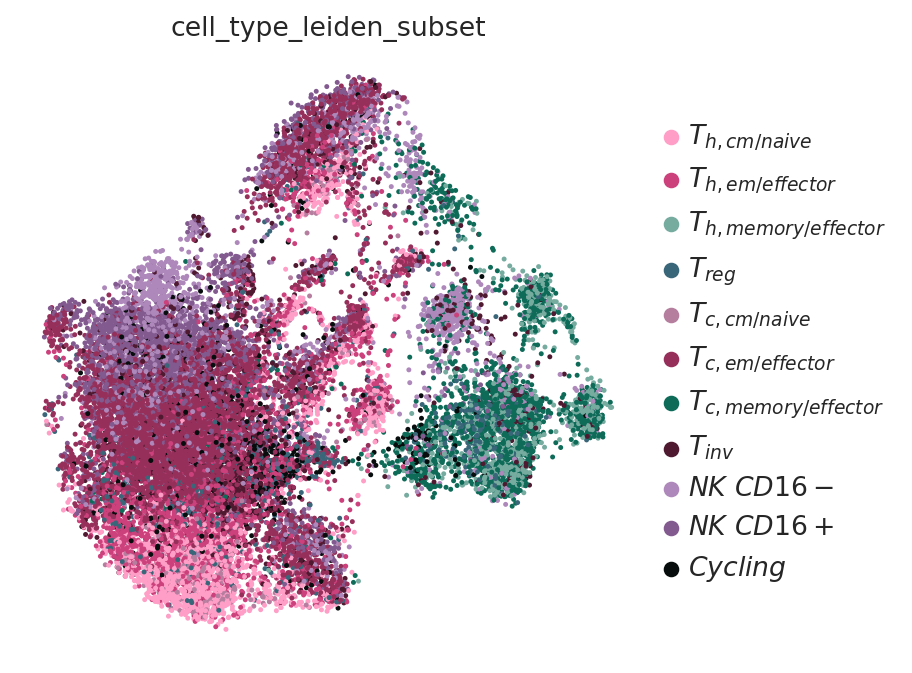

In [18]:
sc.pp.neighbors(adata, use_rep='X_regulon')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type_leiden_subset'], size=20)